In [1]:
##USE conda environment tf
# conda activate tf
import anndata as ad
import scanpy as sc
from matplotlib import rcParams
import pandas as pd
import h5py
import IPython
import numpy as np
import numpy as np
import tensorflow as tf
import harmonypy

2026-07-18 13:10:46.105162: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-18 13:10:46.120186: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784394646.137754 1990624 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784394646.143230 1990624 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-18 13:10:46.162112: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, Optional, Sequence, Tuple, Union

def fraction_along_line_curves(
    adata,
    cat_col: str,                                # e.g. "excitatory_group"
    p0: Tuple[float, float],
    p1: Tuple[float, float],
    bins: int = 60,
    clip_to_segment: bool = True,
    smooth_window: int = 1,                      # rolling mean in bins; 1 = no smoothing
    palette_hex: Optional[Dict[str, str]] = None,# {"RL":"#aaddff","Other":"#d3d3d3",...}
    include: Optional[Sequence[str]] = None,     # restrict/order categories
    order_by: Union[str, int] = "mean",          # "mean" | "median" | "center" | int (bin index)
    top_k: Optional[int] = None,                 # plot only top-k most abundant (after ordering)
    normalize: Optional[str] = None,             # None | "by_max" | "by_sum" | "zscore" | "minmax"
    robust_max_pct: Optional[float] = None,      # e.g. 0.99 to ignore outliers for by_max
    lw: float = 2.5,
    alpha: float = 1.0,
    return_df: bool = False,
    _eps: float = 1e-9,                          # numerical safety
    fill_under: bool = True,
    fill_alpha: float = 0.22,
    show: Optional[Sequence[str]] = None,        # NEW: only show selected curves
    saveas = 'fig.pdf'
):
    """
    Plot fractions of categories along a line segment through spatial coordinates.

    Parameters
    ----------
    show : list of str, optional
        If provided, only these categories will be plotted (but all are still used
        for normalization, ordering, and scaling).
    """
    coords = np.asarray(adata.obsm["spatial"])
    cats = adata.obs[cat_col].astype(str).to_numpy()

    # --- line geometry + projections
    p0 = np.asarray(p0, float); p1 = np.asarray(p1, float)
    v = p1 - p0; L = np.linalg.norm(v)
    if L == 0:
        raise ValueError("p0 and p1 must be different points")
    u = v / L
    t = (coords - p0) @ u
    if clip_to_segment:
        t = np.clip(t, 0, L)

    # --- binning
    edges = np.linspace(0, L, bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bidx = np.clip(np.digitize(t, edges) - 1, 0, bins - 1)

    # --- counts per (bin x category)
    wide = pd.crosstab(pd.Series(bidx, name="bin"),
                       pd.Series(cats, name="category")).astype(float)
    wide = wide.reindex(range(bins), fill_value=0.0).sort_index()

    if wide.columns.has_duplicates:
        wide = wide.T.groupby(level=0).sum().T

    # restrict/order categories (pre-filter)
    if include is not None:
        include = list(dict.fromkeys(include))
        keep = [c for c in include if c in wide.columns]
        if not keep:
            raise ValueError("No categories from `include` found in the data.")
        wide = wide.reindex(columns=keep)

    # --- fractions per bin (sum across cats = 1 for each bin with cells)
    rs = wide.sum(axis=1)
    frac = wide.copy()
    nz = rs > 0
    frac.loc[nz] = frac.loc[nz].div(rs[nz], axis=0)
    frac.loc[~nz] = 0.0

    # --- optional smoothing (along mediolateral axis)
    k = max(1, int(smooth_window))
    frac_sm = frac.rolling(window=k, center=True, min_periods=1).mean() if k > 1 else frac

    # --- choose draw order using UN-normalized abundance so large groups remain on top
    if isinstance(order_by, int):
        idx = int(np.clip(order_by, 0, bins - 1))
        order = frac_sm.iloc[idx].sort_values(ascending=False).index.tolist()
    elif order_by == "center":
        idx = bins // 2
        order = frac_sm.iloc[idx].sort_values(ascending=False).index.tolist()
    elif order_by == "median":
        order = frac_sm.median(axis=0).sort_values(ascending=False).index.tolist()
    else:  # "mean"
        order = frac_sm.mean(axis=0).sort_values(ascending=False).index.tolist()

    if top_k is not None:
        order = order[:int(top_k)]

    # --- per-category normalization across the mediolateral axis
    Y = frac_sm[order].copy()

    def _normalize(df: pd.DataFrame) -> pd.DataFrame:
        if normalize is None:
            return df
        if normalize == "by_max":
            denom = (df.quantile(robust_max_pct, axis=0) if robust_max_pct is not None else df.max(axis=0))
            denom = denom.replace(0.0, np.nan)
            return df.divide(denom + _eps)
        if normalize == "by_sum":
            denom = df.sum(axis=0).replace(0.0, np.nan)
            return df.divide(denom + _eps)
        if normalize == "zscore":
            mu = df.mean(axis=0)
            sd = df.std(axis=0).replace(0.0, np.nan)
            return (df - mu) / (sd + _eps)
        if normalize == "minmax":
            mn = df.min(axis=0)
            mx = df.max(axis=0)
            den = (mx - mn).replace(0.0, np.nan)
            return (df - mn) / (den + _eps)
        raise ValueError("normalize must be None | 'by_max' | 'by_sum' | 'zscore' | 'minmax'")

    Y_norm = _normalize(Y)

    # --- plot (lines + shaded area under each curve)
    fig, ax = plt.subplots(figsize=(12, 4))

    # --- FILTER: show only selected categories if provided ---
    plot_order = order[::-1]  # least abundant first
    if show is not None:
        show = set(show)
        plot_order = [c for c in plot_order if c in show]
        if not plot_order:
            raise ValueError("None of the categories in `show` were found in the data.")

    for c in plot_order:
        y = np.asarray(Y_norm[c], dtype=float).ravel()
        color = (palette_hex.get(c) if palette_hex else None)
        (ln,) = ax.plot(centers, y, label=c, lw=lw, alpha=alpha, color=color, zorder=3)
        if fill_under:
            fc = color if color is not None else ln.get_color()
            y0 = np.zeros_like(y)
            mask = ~np.isnan(y)
            ax.fill_between(centers, y0, y, where=mask, color=fc, alpha=fill_alpha, linewidth=0, zorder=2)

    ax.set_xlim(0, L)
    # sensible y-lims based on normalization mode
    if normalize in ("by_max", "minmax"):
        ax.set_ylim(0, 1)
    else:
        y_min = np.nanmin(Y_norm.values)
        y_max = np.nanmax(Y_norm.values)
        pad = 0.05 * (y_max - y_min + _eps)
        ax.set_ylim(y_min - pad, y_max + pad)

    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.savefig(saveas, bbox_inches="tight")
    if return_df:
        # long-form of BOTH raw fraction and the plotted (possibly normalized) values
        long_raw = (Y.rename_axis("bin").reset_index()
                      .melt(id_vars="bin", var_name="category", value_name="fraction"))
        long_raw["t_center"] = centers[long_raw["bin"].to_numpy()]

        long_norm = (Y_norm.rename_axis("bin").reset_index()
                        .melt(id_vars="bin", var_name="category", value_name="value"))
        long_norm["t_center"] = centers[long_norm["bin"].to_numpy()]
        return (long_norm, Y_norm, long_raw, Y)


In [3]:
adata_all = ad.read_h5ad("all_slices_all_tp_11-18-25.h5ad")


In [4]:
np.unique(adata_all.obs['cell_types'])

array(['Astroglia', 'Choroid Plexus', 'Glia/Oligodendrocytes',
       'Granule cells', 'Interposed/Lateral DCN', 'Medial DCN',
       'Midbrain-fated cells', 'Molecular Layer Interneurons',
       'Outside Cb', 'Purkinje Cells', 'i1'], dtype=object)

/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


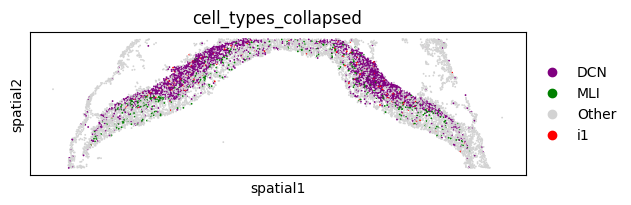

/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


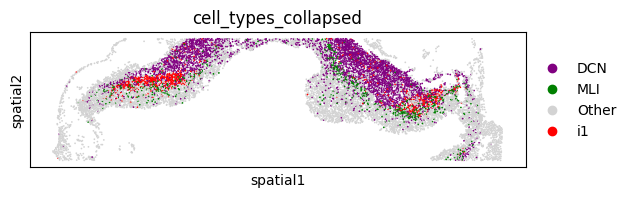

/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


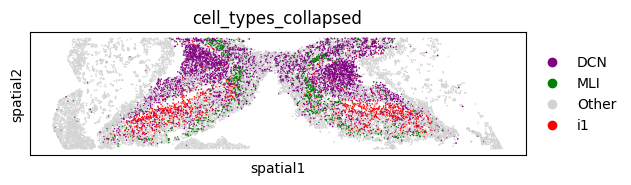

/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


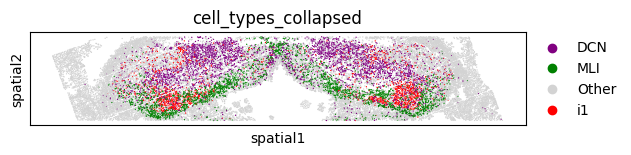

/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


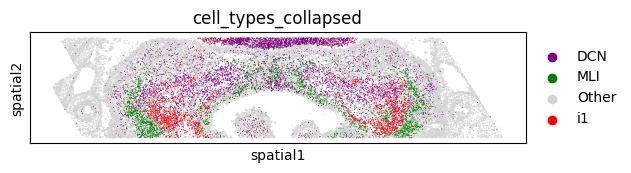

/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


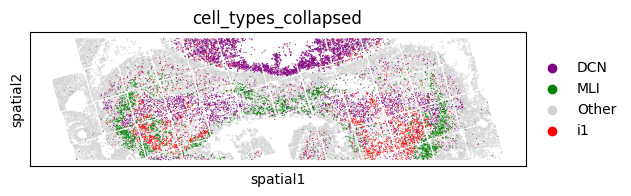

/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


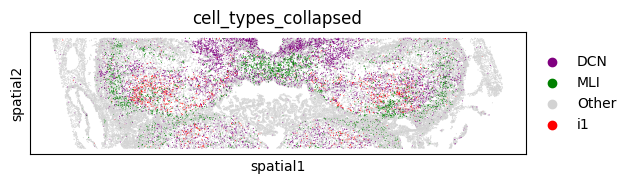

/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


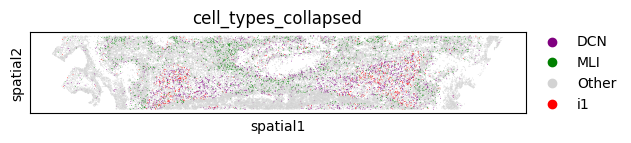

/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


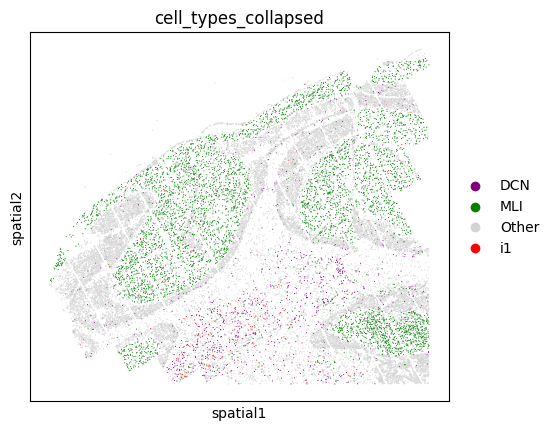

In [5]:
import numpy as np

# Define groups
dcn_types = ["Medial DCN", "Interposed/Lateral DCN", "DCN", "Midbrain-fated cells"]

def collapse_types(x):
    if x in dcn_types:
        return "DCN"
    elif x == "i1":
        return "i1"
    elif x == "Molecular Layer Interneurons":
        return "MLI"
    else:
        return "Other"

adata_all.obs["cell_types_collapsed"] = adata_all.obs["cell_types"].apply(collapse_types)

palette = {
    "Other": "lightgrey",
    "DCN": "purple",
    "i1": "red",
    "MLI": "green",
}

import numpy as np

# get gene indices
slc_idx = np.where(adata_all.var_names == "Slc17a6")[0][0]
gad_idx = np.where(adata_all.var_names == "Gad1")[0][0]

# extract counts
slc_counts = adata_all.X[:, slc_idx].A1 if hasattr(adata_all.X, "A1") else adata_all.X[:, slc_idx]
gad_counts = adata_all.X[:, gad_idx].A1 if hasattr(adata_all.X, "A1") else adata_all.X[:, gad_idx]

# build mask
mask = np.ones(adata_all.n_obs, dtype=bool)

# remove i1 or MLI with Slc17a6 > 2
mask &= ~(
    adata_all.obs["cell_types_collapsed"].isin(["i1", "MLI"]) &
    (slc_counts > 0) #& (gad_counts < 1)
)

# remove DCN with Gad1 > 2
mask &= ~(
    (adata_all.obs["cell_types_collapsed"] == "DCN") &
    (gad_counts > 0) #& (slc_counts < 1)
)

# subset
adata_filtered = adata_all[mask].copy()

# plot
for i in np.unique(adata_filtered.obs["library_id"]):
    sc.pl.spatial(
        adata_filtered[adata_filtered.obs["library_id"] == i],
        color="cell_types_collapsed",
        palette=palette,
        spot_size=70
    )

In [6]:
np.unique(adata_all.obs["library_id"])

array(['e11_1', 'e12_1', 'e13_5', 'e14_2', 'e15_2', 'e17_1', 'p0_1',
       'p4_2', 'p56_1'], dtype=object)

In [57]:
e11 = adata_all[adata_all.obs["library_id"] == "e11_1"]
e12 = adata_all[adata_all.obs["library_id"] == "e12_1"]
e13 = adata_all[adata_all.obs["library_id"] == "e13_5"]
e14 = adata_all[adata_all.obs["library_id"] == "e14_2"]
e15 = adata_all[adata_all.obs["library_id"] == "e15_2"]
e17 = adata_all[adata_all.obs["library_id"] == "e17_1"]
p0_ = adata_all[adata_all.obs["library_id"] == "p0_1"]
p4 = adata_all[adata_all.obs["library_id"] == "p4_2"]
p56 = adata_all[adata_all.obs["library_id"] == "p56_1"]


In [60]:
p0_

View of AnnData object with n_obs × n_vars = 52356 × 1737
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'cell_types', 'cell_types_collapsed'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'mean', 'std'
    uns: 'cell_types_colors', 'dendrogram_cell_types', 'library_id_colors', 'neighbors', 'pca', 'umap', 'wilcoxon'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

28610 cells kept out of 12715


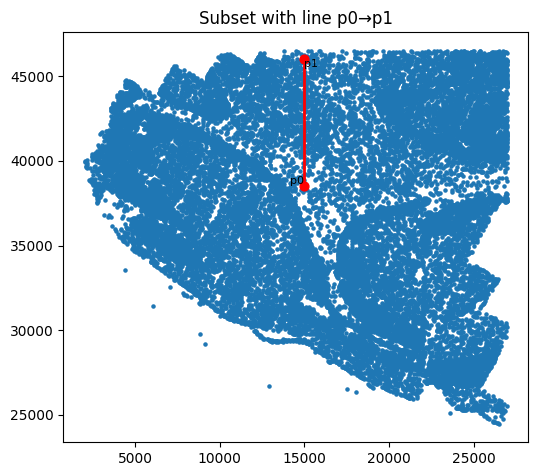

In [72]:
import numpy as np
import matplotlib.pyplot as plt

# mask where x > 10000
mask = p56.obsm["spatial"][:, 0] < 38000

# subset
e11_sub = p56[mask].copy()

# quick check
print(mask.sum(), "cells kept out of", e12.n_obs)

# endpoints (same coordinate system as .obsm["spatial"])
p0 = (15000,38500)
p1 = (15000,46000)

# plot
plt.figure(figsize=(6, 6))
plt.scatter(e11_sub.obsm["spatial"][:, 0], e11_sub.obsm["spatial"][:, 1], s=5)

# line segment and endpoints
plt.plot([p0[0], p1[0]], [p0[1], p1[1]], lw=2, color="red")
plt.scatter([p0[0], p1[0]], [p0[1], p1[1]], s=40, color="red")
plt.text(p0[0], p0[1], "p0", ha="right", va="bottom", fontsize=8)
plt.text(p1[0], p1[1], "p1", ha="left", va="top", fontsize=8)

plt.gca().set_aspect("equal", adjustable="box")
plt.title("Subset with line p0→p1")
plt.show()


/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


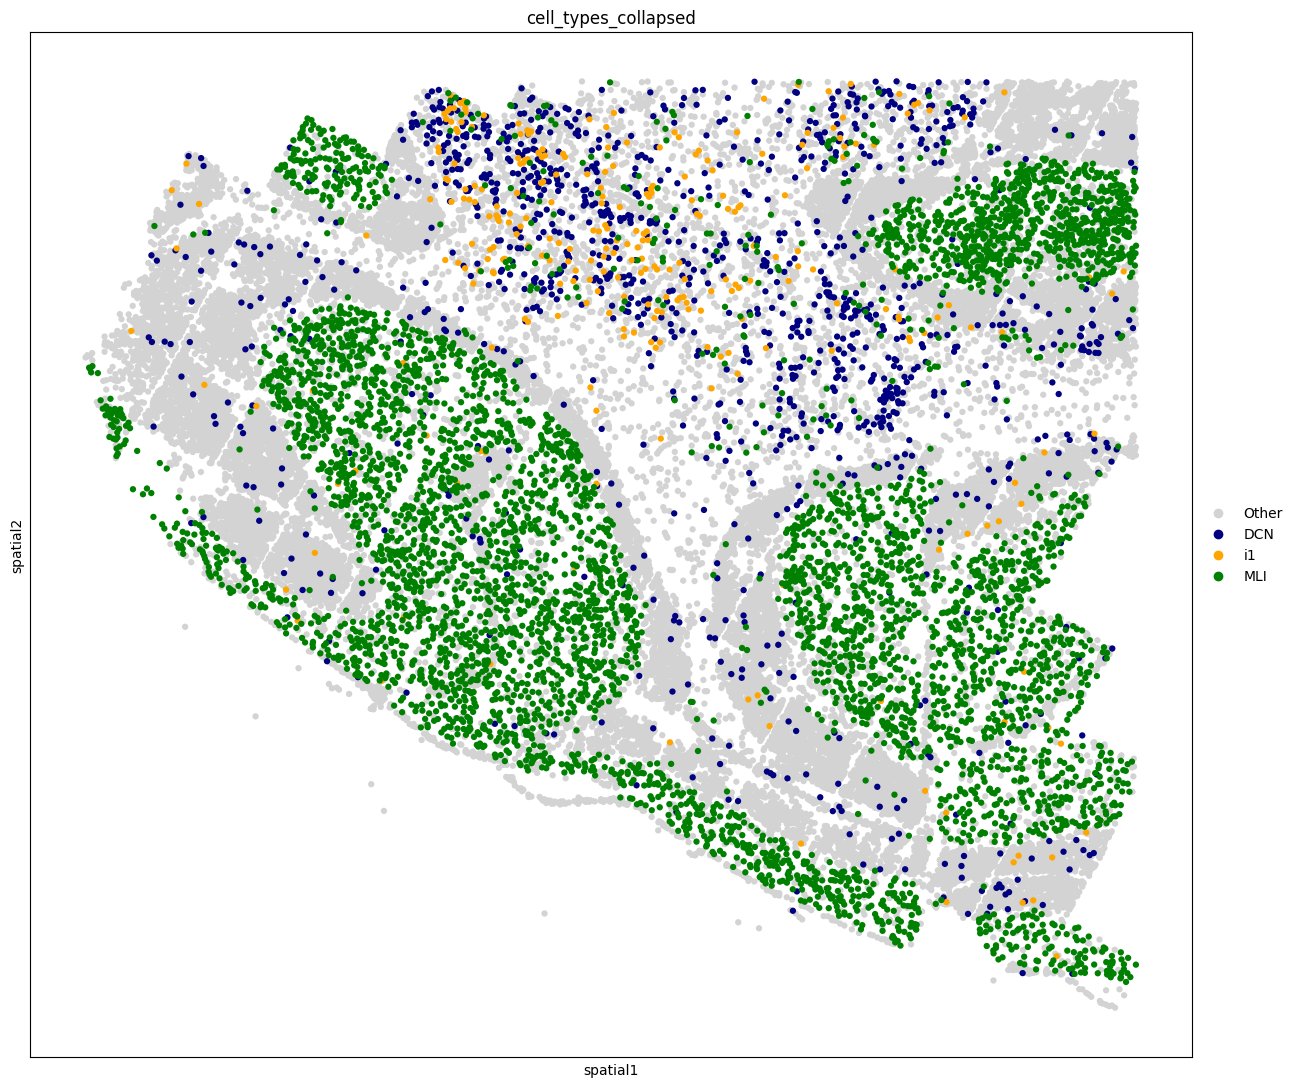

In [73]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd

# desired plotting order
order = ["Other", "DCN", "i1", "MLI"]
ct = ["Other", "i1", "DCN", "MLI"]

# enforce categorical order
e11_sub.obs["cell_types_collapsed"] = pd.Categorical(
    e11_sub.obs["cell_types_collapsed"],
    categories=order,
    ordered=True
)

palette = {
    "DCN": "navy",
    "i1": "orange",
    "MLI": "green",
    "Other": "lightgrey"
}


fig, ax = plt.subplots(figsize = (15,15))

for ct in order:
    sc.pl.spatial(
        e11_sub[e11_sub.obs["cell_types_collapsed"] == ct],
        color="cell_types_collapsed",
        palette=palette,
        spot_size=150,
        ax=ax,
        show=False
    )

plt.savefig("figure3/e11_spatial_inhib.pdf", bbox_inches="tight", transparent=True)
plt.show()

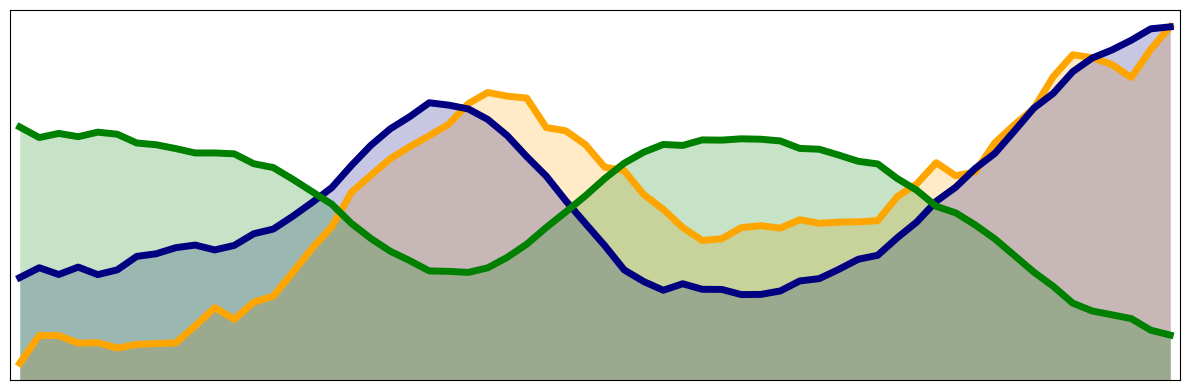

In [75]:
palette_hex = {
    "DCN": "navy",
    "i1": "orange",
    "MLI": "green",#"#earlyInt/Lat"
    #"DCN8": "#00a86b"        # green
}


wide_df_e11 = fraction_along_line_curves(
    e11_sub,
    cat_col="cell_types_collapsed",
    p0=p0, p1=p1,
    bins=60,
    clip_to_segment=True,
    smooth_window=10,         # set to 1 to disable smoothing
    lw = 5,
    palette_hex=palette_hex,
    normalize="by_sum",
    include=["DCN", "i1", "MLI"],
    return_df=True,
    saveas = "figure3/e11_medlat.pdf"
)




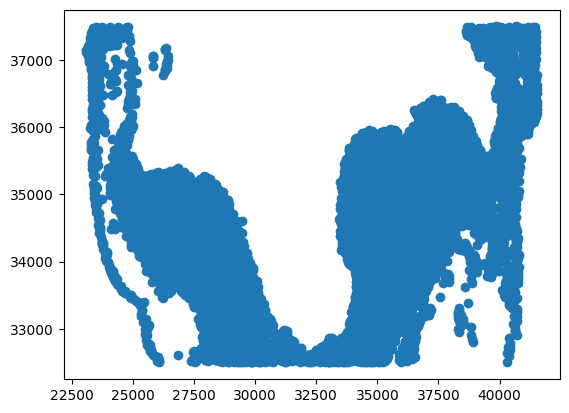

In [8]:
e12 = adata_all[adata_all.obs["library_id"] == "e12_1"]
plt.scatter(e12.obsm['spatial'][:,0], e12.obsm['spatial'][:,1])

4693 cells kept out of 12715


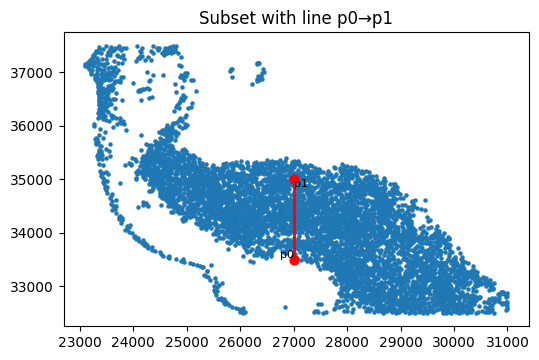

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# mask where x > 10000
mask = e12.obsm["spatial"][:, 0] < 31000

# subset
e11_sub = e12[mask].copy()

# quick check
print(mask.sum(), "cells kept out of", e12.n_obs)

# endpoints (same coordinate system as .obsm["spatial"])
p0 = (27000, 33500)
p1 = (27000, 35000)

# plot
plt.figure(figsize=(6, 6))
plt.scatter(e11_sub.obsm["spatial"][:, 0], e11_sub.obsm["spatial"][:, 1], s=5)

# line segment and endpoints
plt.plot([p0[0], p1[0]], [p0[1], p1[1]], lw=2, color="red")
plt.scatter([p0[0], p1[0]], [p0[1], p1[1]], s=40, color="red")
plt.text(p0[0], p0[1], "p0", ha="right", va="bottom", fontsize=8)
plt.text(p1[0], p1[1], "p1", ha="left", va="top", fontsize=8)

plt.gca().set_aspect("equal", adjustable="box")
plt.title("Subset with line p0→p1")
plt.show()


/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


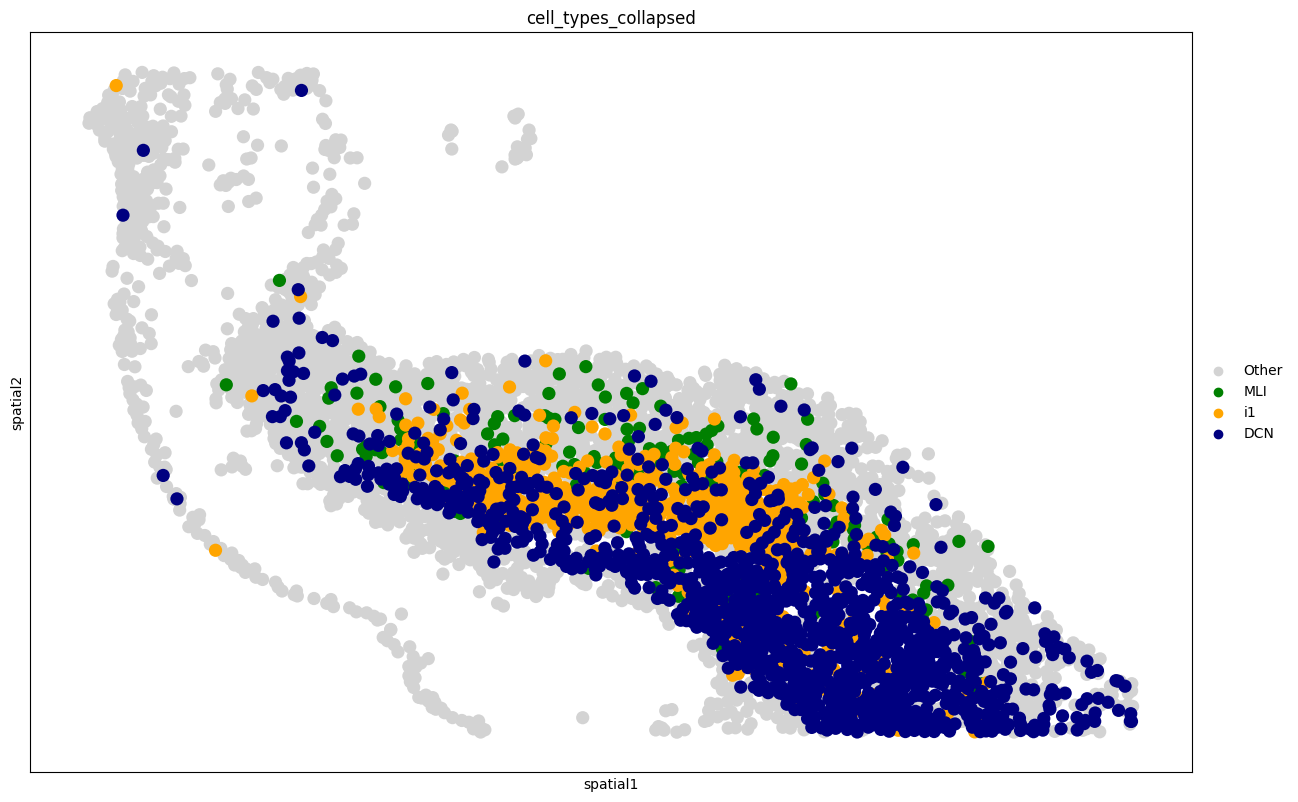

In [10]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd

# desired plotting order
order = ["Other", "MLI", "i1", "DCN"]

# enforce categorical order
e11_sub.obs["cell_types_collapsed"] = pd.Categorical(
    e11_sub.obs["cell_types_collapsed"],
    categories=order,
    ordered=True
)

palette = {
    "DCN": "navy",
    "i1": "orange",
    "MLI": "green",
    "Other": "lightgrey"
}


fig, ax = plt.subplots(figsize = (15,15))

for ct in order:
    sc.pl.spatial(
        e11_sub[e11_sub.obs["cell_types_collapsed"] == ct],
        color="cell_types_collapsed",
        palette=palette,
        spot_size=100,
        ax=ax,
        show=False
    )

plt.savefig("figure3/e12_spatial_inhib.pdf", bbox_inches="tight", transparent=True)
plt.show()

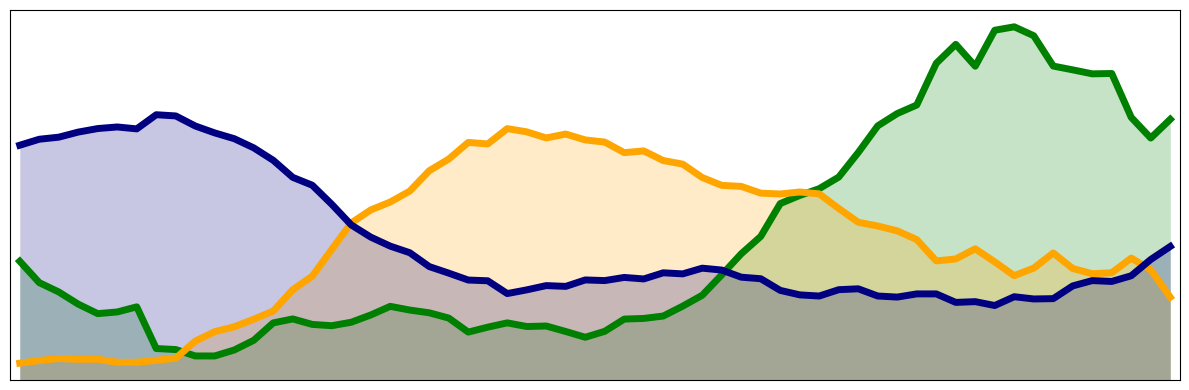

In [11]:
palette_hex = {
    "DCN": "navy",
    "i1": "orange",
    "MLI": "green",#"#earlyInt/Lat"
    #"DCN8": "#00a86b"        # green
}


wide_df_e11 = fraction_along_line_curves(
    e11_sub,
    cat_col="cell_types_collapsed",
    p0=p0, p1=p1,
    bins=60,
    clip_to_segment=True,
    smooth_window=10,         # set to 1 to disable smoothing
    lw = 5,
    palette_hex=palette_hex,
    normalize="by_sum",
    include=["DCN", "i1", "MLI"],
    return_df=True,
    saveas = "figure3/e12_medlat.pdf"
)




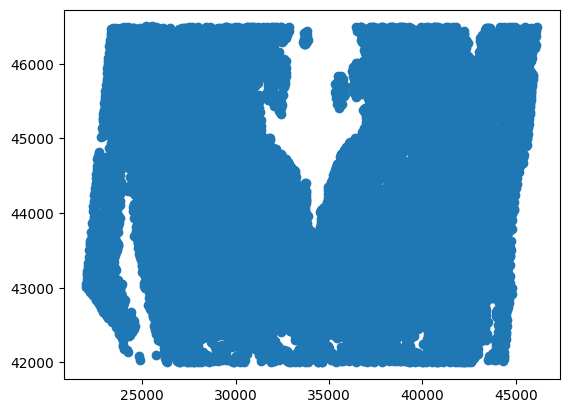

In [59]:
e14 = adata_all[adata_all.obs["library_id"] == "e14_2"]
plt.scatter(e14.obsm['spatial'][:,0], e14.obsm['spatial'][:,1])

9324 cells kept out of 24326


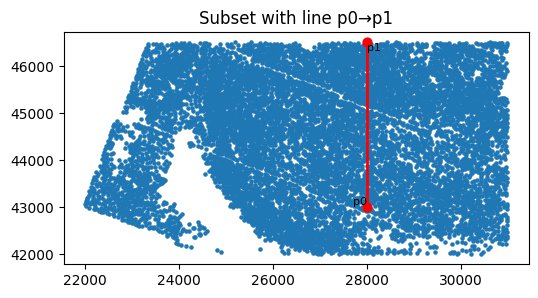

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# mask where x > 10000
mask = e14.obsm["spatial"][:, 0] < 31000

# subset
e11_sub = e14[mask].copy()

# quick check
print(mask.sum(), "cells kept out of", e14.n_obs)

# endpoints (same coordinate system as .obsm["spatial"])
p0 = (28000, 43000)
p1 = (28000, 46500)

# plot
plt.figure(figsize=(6, 6))
plt.scatter(e11_sub.obsm["spatial"][:, 0], e11_sub.obsm["spatial"][:, 1], s=5)

# line segment and endpoints
plt.plot([p0[0], p1[0]], [p0[1], p1[1]], lw=2, color="red")
plt.scatter([p0[0], p1[0]], [p0[1], p1[1]], s=40, color="red")
plt.text(p0[0], p0[1], "p0", ha="right", va="bottom", fontsize=8)
plt.text(p1[0], p1[1], "p1", ha="left", va="top", fontsize=8)

plt.gca().set_aspect("equal", adjustable="box")
plt.title("Subset with line p0→p1")
plt.show()


/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


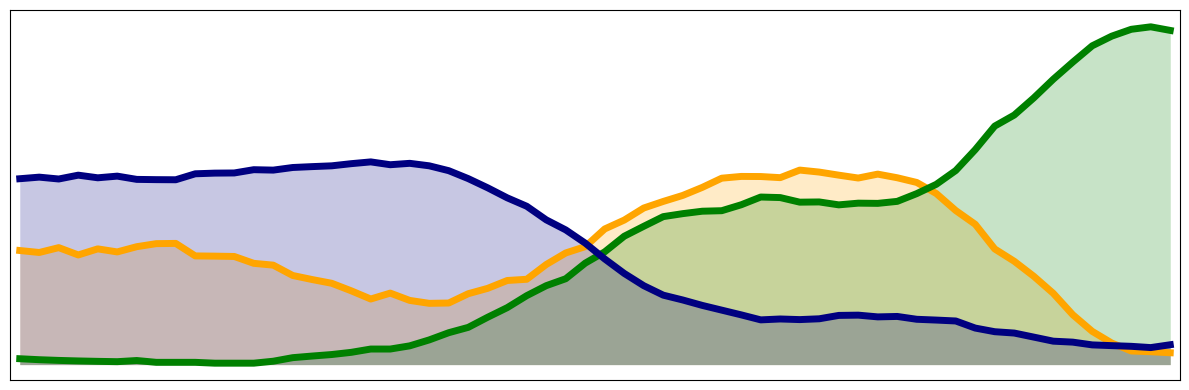

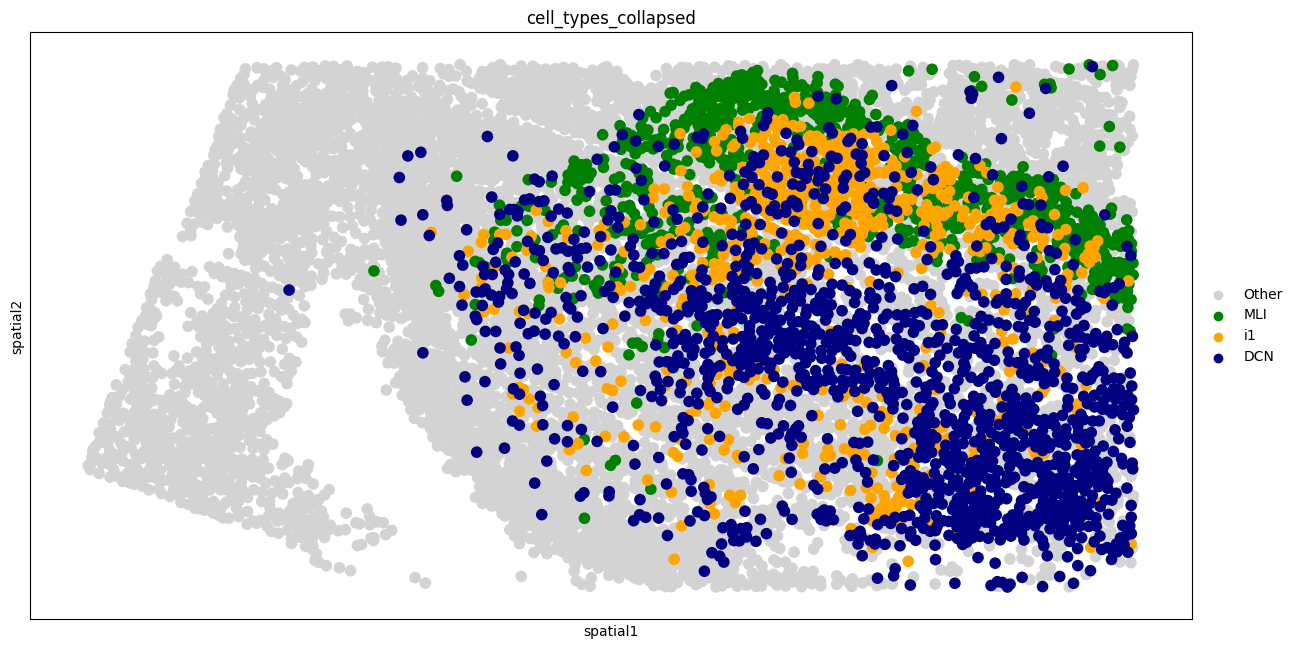

In [61]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd

# desired plotting order
order = ["Other", "MLI", "i1", "DCN"]

# enforce categorical order
e11_sub.obs["cell_types_collapsed"] = pd.Categorical(
    e11_sub.obs["cell_types_collapsed"],
    categories=order,
    ordered=True
)

palette_hex = {
    "DCN": "navy",
    "i1": "orange",
    "MLI": "green",#"#earlyInt/Lat"
    #"DCN8": "#00a86b"        # green
}


wide_df_e11 = fraction_along_line_curves(
    e11_sub,
    cat_col="cell_types_collapsed",
    p0=p0, p1=p1,
    bins=60,
    clip_to_segment=True,
    smooth_window=10,         # set to 1 to disable smoothing
    lw = 5,
    palette_hex=palette_hex,
    normalize="by_sum",
    include=["DCN", "i1", "MLI"],
    return_df=True,
    saveas = "figure3/e12_medlat.pdf"
)




fig, ax = plt.subplots(figsize = (15,15))

for ct in order:
    sc.pl.spatial(
        e11_sub[e11_sub.obs["cell_types_collapsed"] == ct],
        color="cell_types_collapsed",
        palette=palette,
        spot_size=100,
        ax=ax,
        show=False
    )
plt.savefig("figure3/e14_spatial_inhib.pdf", bbox_inches="tight", transparent=True)
plt.show()

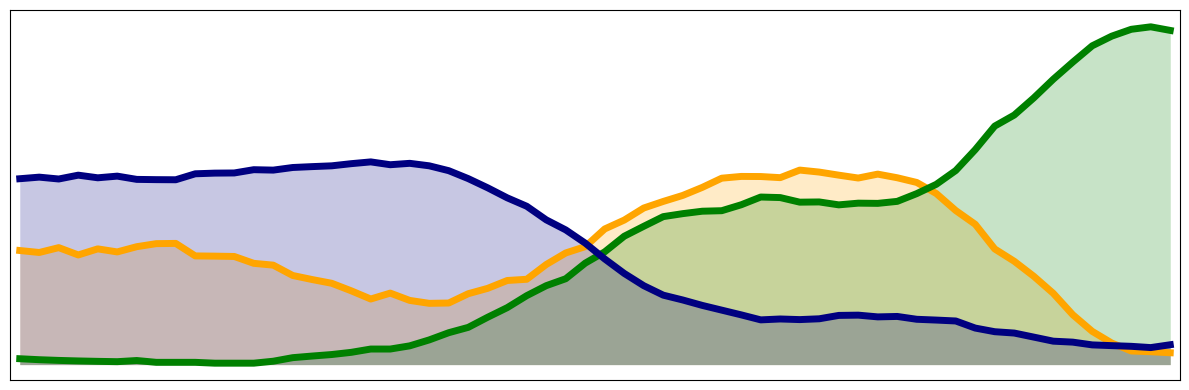

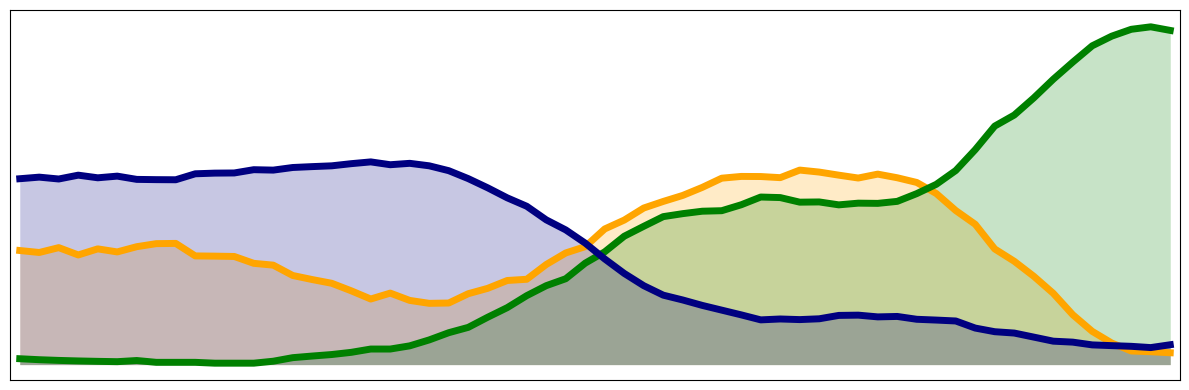

In [62]:
palette_hex = {
    "DCN": "navy",
    "i1": "orange",
    "MLI": "green",#"#earlyInt/Lat"
    #"DCN8": "#00a86b"        # green
}


wide_df_e11 = fraction_along_line_curves(
    e11_sub,
    cat_col="cell_types_collapsed",
    p0=p0, p1=p1,
    bins=60,
    clip_to_segment=True,
    smooth_window=10,         # set to 1 to disable smoothing
    lw = 5,
    palette_hex=palette_hex,
    normalize="by_sum",
    include=["DCN", "i1", "MLI"],
    return_df=True,
    saveas = "figure3/e12_medlat.pdf"
)




wide_df_e11 = fraction_along_line_curves(
    e11_sub,
    cat_col="cell_types_collapsed",
    p0=p0, p1=p1,
    bins=60,
    clip_to_segment=True,
    smooth_window=10,         # set to 1 to disable smoothing
    lw = 5,
    palette_hex=palette_hex,
    normalize="by_sum",
    include=["DCN", "i1", "MLI"],
    return_df=True,
    saveas = "figure3/e14_medlat.pdf")


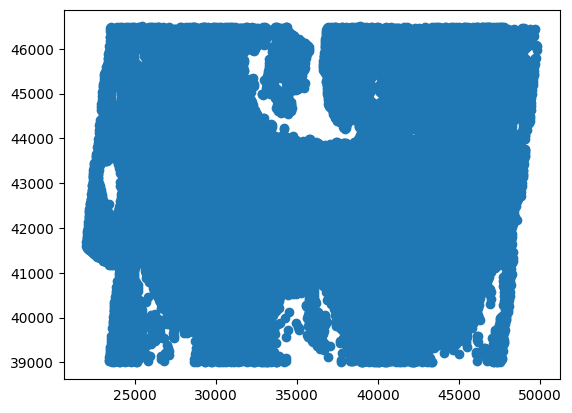

In [73]:
e17 = adata_all[adata_all.obs["library_id"] == "e17_1"]
plt.scatter(e17.obsm['spatial'][:,0], e17.obsm['spatial'][:,1])

17708 cells kept out of 37605


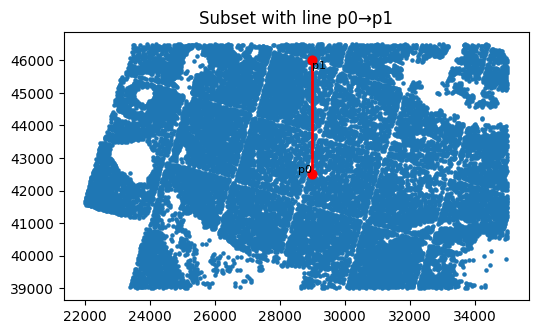

In [74]:
import numpy as np
import matplotlib.pyplot as plt

# mask where x > 10000
mask = e17.obsm["spatial"][:, 0] < 35000

# subset
e11_sub = e17[mask].copy()

# quick check
print(mask.sum(), "cells kept out of", e17.n_obs)

# endpoints (same coordinate system as .obsm["spatial"])
p0 = (29000, 42500)
p1 = (29000, 46000)

# plot
plt.figure(figsize=(6, 6))
plt.scatter(e11_sub.obsm["spatial"][:, 0], e11_sub.obsm["spatial"][:, 1], s=5)

# line segment and endpoints
plt.plot([p0[0], p1[0]], [p0[1], p1[1]], lw=2, color="red")
plt.scatter([p0[0], p1[0]], [p0[1], p1[1]], s=40, color="red")
plt.text(p0[0], p0[1], "p0", ha="right", va="bottom", fontsize=8)
plt.text(p1[0], p1[1], "p1", ha="left", va="top", fontsize=8)

plt.gca().set_aspect("equal", adjustable="box")
plt.title("Subset with line p0→p1")
plt.show()


/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


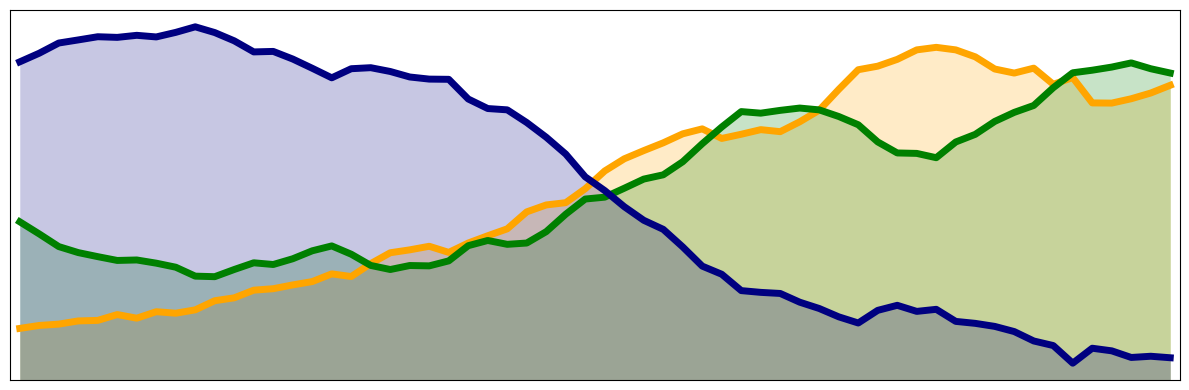

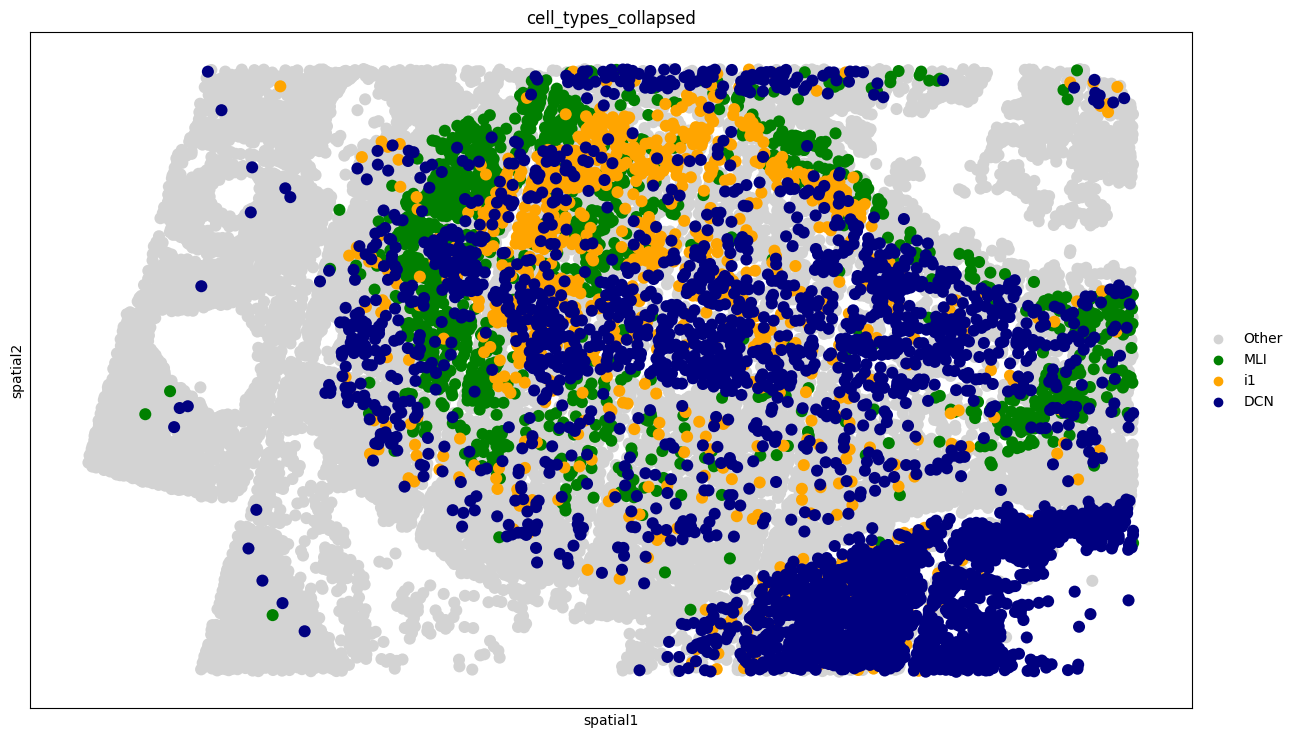

In [75]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd

# desired plotting order
order = ["Other", "MLI", "i1", "DCN"]

# enforce categorical order
e11_sub.obs["cell_types_collapsed"] = pd.Categorical(
    e11_sub.obs["cell_types_collapsed"],
    categories=order,
    ordered=True
)

palette = {
    "DCN": "navy",
    "i1": "orange",
    "MLI": "green",
    "Other": "lightgrey"
}
palette_hex = {
    "DCN": "navy",
    "i1": "orange",
    "MLI": "green",#"#earlyInt/Lat"
    #"DCN8": "#00a86b"        # green
}


wide_df_e11 = fraction_along_line_curves(
    e11_sub,
    cat_col="cell_types_collapsed",
    p0=p0, p1=p1,
    bins=60,
    clip_to_segment=True,
    smooth_window=10,         # set to 1 to disable smoothing
    lw = 5,
    palette_hex=palette_hex,
    normalize="by_sum",
    include=["DCN", "i1", "MLI"],
    return_df=True,
    saveas = "figure3/e12_medlat.pdf"
)




fig, ax = plt.subplots(figsize = (15,15))

for ct in order:
    sc.pl.spatial(
        e11_sub[e11_sub.obs["cell_types_collapsed"] == ct],
        color="cell_types_collapsed",
        palette=palette,
        spot_size=150,
        ax=ax,
        show=False
    )
plt.savefig("figure3/e17_spatial_inhib.pdf", bbox_inches="tight", transparent=True)
plt.show()
plt.show()

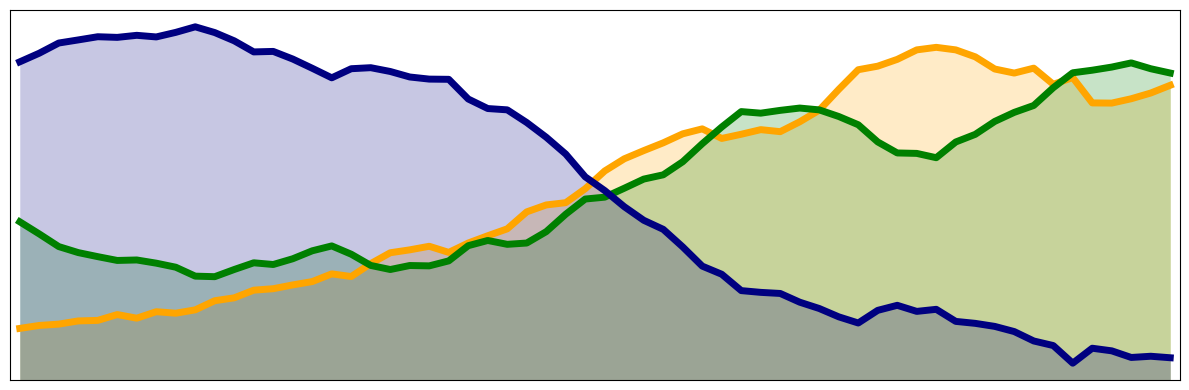

In [31]:
palette_hex = {
    "DCN": "navy",
    "i1": "orange",
    "MLI": "green",#"#earlyInt/Lat"
    #"DCN8": "#00a86b"        # green
}


wide_df_e11 = fraction_along_line_curves(
    e11_sub,
    cat_col="cell_types_collapsed",
    p0=p0, p1=p1,
    bins=60,
    clip_to_segment=True,
    smooth_window=10,         # set to 1 to disable smoothing
    lw = 5,
    palette_hex=palette_hex,
    normalize="by_sum",
    include=["DCN", "i1", "MLI"],
    return_df=True,
    saveas = "figure3/e17_medlat.pdf"
)

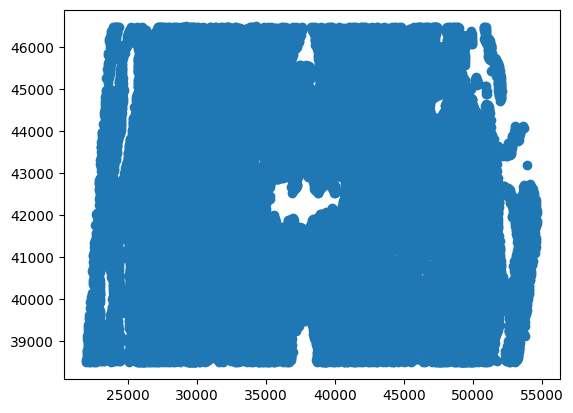

In [32]:
p0 = adata_all[adata_all.obs["library_id"] == "p0_1"]
plt.scatter(p0.obsm['spatial'][:,0], p0.obsm['spatial'][:,1])

23687 cells kept out of 52356


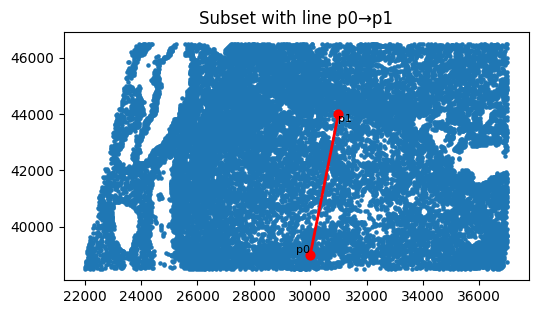

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# mask where x > 10000
mask = p0.obsm["spatial"][:, 0] < 37000

# subset
e11_sub = p0[mask].copy()

# quick check
print(mask.sum(), "cells kept out of", p0.n_obs)

# endpoints (same coordinate system as .obsm["spatial"])
p0 = (30000, 39000)
p1 = (31000, 44000)

# plot
plt.figure(figsize=(6, 6))
plt.scatter(e11_sub.obsm["spatial"][:, 0], e11_sub.obsm["spatial"][:, 1], s=5)

# line segment and endpoints
plt.plot([p0[0], p1[0]], [p0[1], p1[1]], lw=2, color="red")
plt.scatter([p0[0], p1[0]], [p0[1], p1[1]], s=40, color="red")
plt.text(p0[0], p0[1], "p0", ha="right", va="bottom", fontsize=8)
plt.text(p1[0], p1[1], "p1", ha="left", va="top", fontsize=8)

plt.gca().set_aspect("equal", adjustable="box")
plt.title("Subset with line p0→p1")
plt.show()


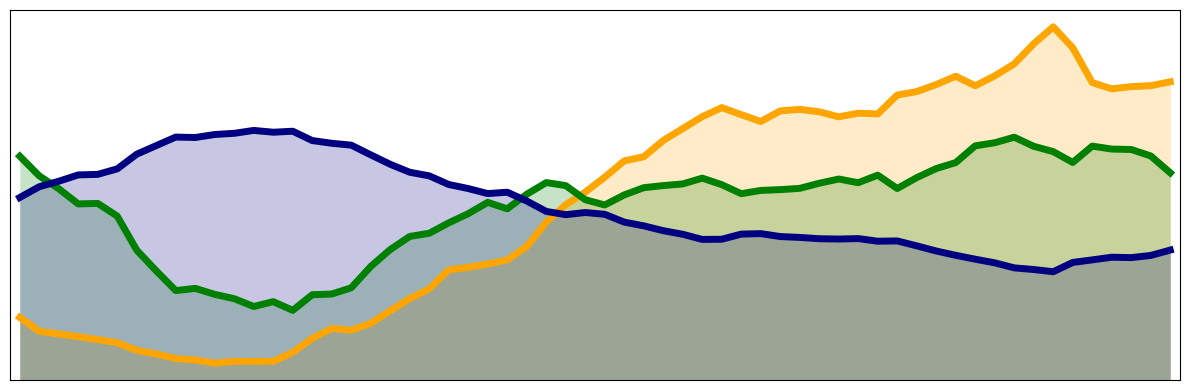

In [34]:
palette_hex = {
    "DCN": "navy",
    "i1": "orange",
    "MLI": "green",#"#earlyInt/Lat"
    #"DCN8": "#00a86b"        # green
}


wide_df_e11 = fraction_along_line_curves(
    e11_sub,
    cat_col="cell_types_collapsed",
    p0=p0, p1=p1,
    bins=60,
    clip_to_segment=True,
    smooth_window=10,         # set to 1 to disable smoothing
    lw = 5,
    palette_hex=palette_hex,
    normalize="by_sum",
    include=["DCN", "i1", "MLI"],
    return_df=True,
)

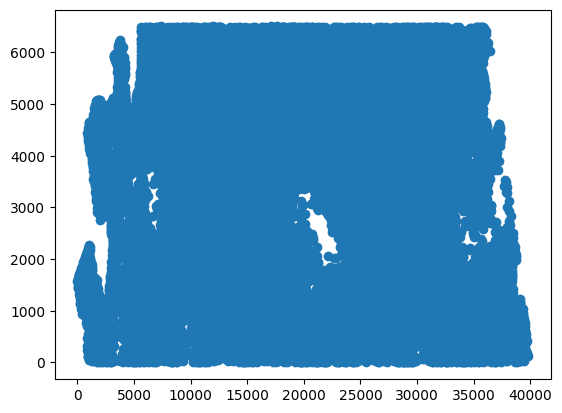

In [67]:
p4 = adata_all[adata_all.obs["library_id"] == "p4_2"]
plt.scatter(p4.obsm['spatial'][:,0], p4.obsm['spatial'][:,1])

20577 cells kept out of 42472


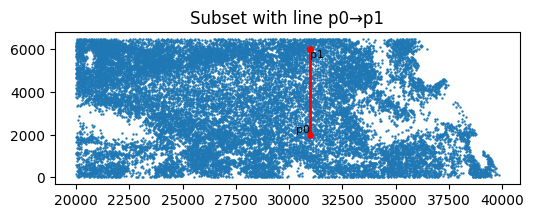

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# mask where x > 10000
mask = p4.obsm["spatial"][:, 0]> 20000

# subset
e11_sub = p4[mask].copy()

# quick check
print(mask.sum(), "cells kept out of", p4.n_obs)

# endpoints (same coordinate system as .obsm["spatial"])
p0 = (31000, 2000)
p1 = (31000, 6000)

# plot
plt.figure(figsize=(6, 6))
plt.scatter(e11_sub.obsm["spatial"][:, 0], e11_sub.obsm["spatial"][:, 1], s=0.5)

# line segment and endpoints
plt.plot([p0[0], p1[0]], [p0[1], p1[1]], lw=2, color="red")
plt.scatter([p0[0], p1[0]], [p0[1], p1[1]], s=15, color="red")
plt.text(p0[0], p0[1], "p0", ha="right", va="bottom", fontsize=8)
plt.text(p1[0], p1[1], "p1", ha="left", va="top", fontsize=8)

plt.gca().set_aspect("equal", adjustable="box")
plt.title("Subset with line p0→p1")
plt.show()


/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


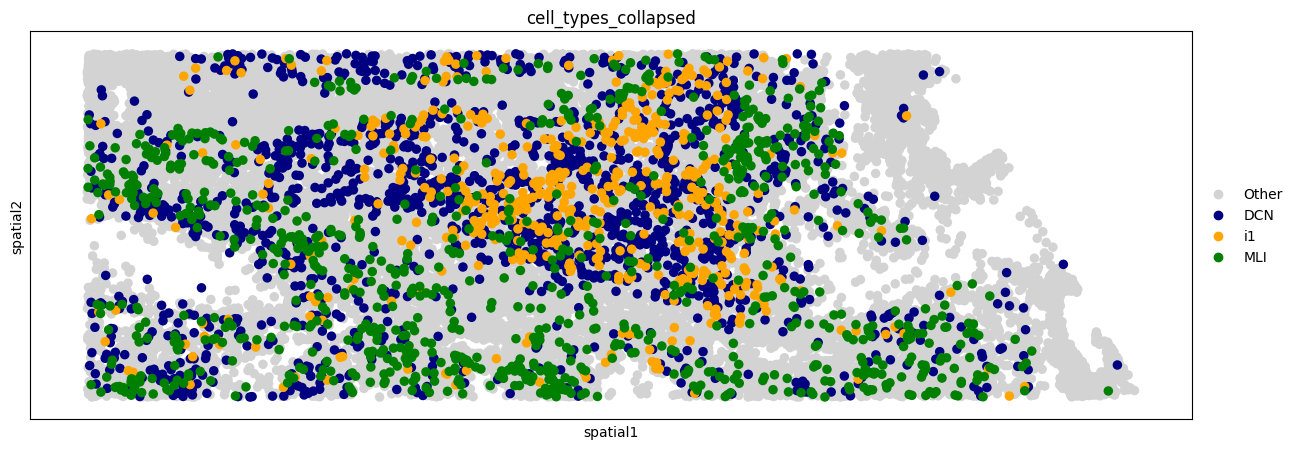

In [71]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd

# desired plotting order
order = ["Other", "DCN", "i1", "MLI", ]

# enforce categorical order
e11_sub.obs["cell_types_collapsed"] = pd.Categorical(
    e11_sub.obs["cell_types_collapsed"],
    categories=order,
    ordered=True
)

palette = {
    
    "i1": "orange",
    "MLI": "green",
    "DCN": "navy",
    "Other": "lightgrey"
}

fig, ax = plt.subplots(figsize = (15,15))

for ct in order:
    sc.pl.spatial(
        e11_sub[e11_sub.obs["cell_types_collapsed"] == ct],
        color="cell_types_collapsed",
        palette=palette,
        spot_size=180,
        ax=ax,
        show=False
    )
plt.savefig("figure3/p4_spatial_inhib.pdf", bbox_inches="tight", transparent=True)
plt.show()
plt.show()

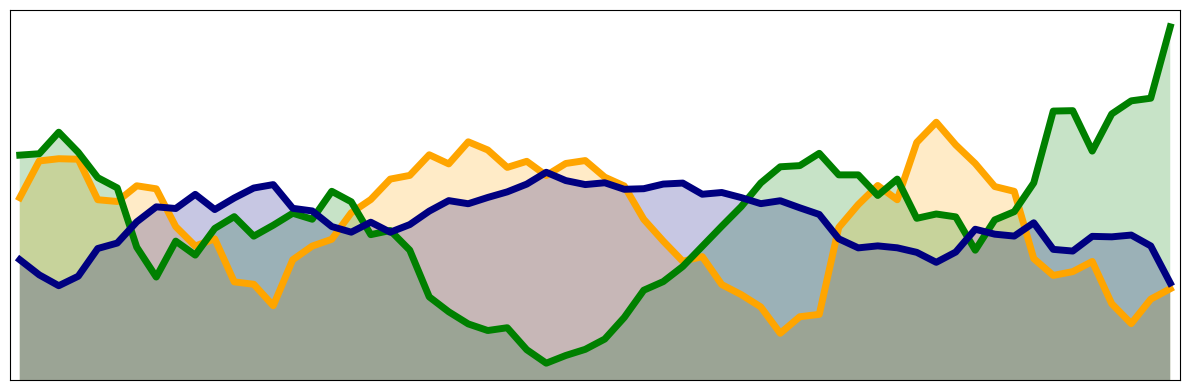

In [72]:
palette_hex = {
    "DCN": "navy",
    "i1": "orange",
    "MLI": "green",#"#earlyInt/Lat"
    #"DCN8": "#00a86b"        # green
}


wide_df_e11 = fraction_along_line_curves(
    e11_sub,
    cat_col="cell_types_collapsed",
    p0=p0, p1=p1,
    bins=60,
    clip_to_segment=True,
    smooth_window=10,         # set to 1 to disable smoothing
    lw = 5,
    palette_hex=palette_hex,
    normalize="by_sum",
    include=["DCN", "i1", "MLI"],
    return_df=True,
    saveas = "figure3/p4_medlat.pdf"
)

## Nearest Neighbors

In [58]:
e11 = adata_filtered[adata_filtered.obs["library_id"] == "e11_1"]
e12 = adata_filtered[adata_filtered.obs["library_id"] == "e12_1"]
e13 = adata_filtered[adata_filtered.obs["library_id"] == "e13_5"]
e14 = adata_filtered[adata_filtered.obs["library_id"] == "e14_2"]
e15 = adata_filtered[adata_filtered.obs["library_id"] == "e15_2"]
e17 = adata_filtered[adata_filtered.obs["library_id"] == "e17_1"]
p0 = adata_filtered[adata_filtered.obs["library_id"] == "p0_1"]
p4 = adata_filtered[adata_filtered.obs["library_id"] == "p4_2"]
p56 = adata_filtered[adata_filtered.obs["library_id"] == "p56_1"]


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

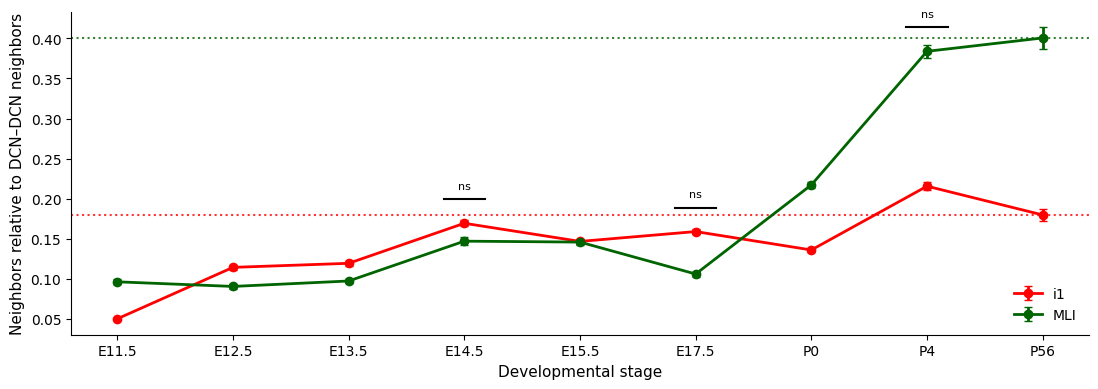

In [30]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from scipy.stats import sem, ttest_ind
import matplotlib.pyplot as plt
import matplotlib as mpl

# -------------------------
# style
# -------------------------
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["svg.fonttype"] = "none"

# -------------------------
# datasets
# -------------------------
datasets = {
    "E11.5": e11,
    "E12.5": e12,
    "E13.5": e13,
    "E14.5": e14,
    "E15.5": e15,
    "E17.5": e17,
    "P0": p0,
    "P4": p4,
    "P56": p56
}

order = ["E11.5","E12.5","E13.5","E14.5","E15.5","E17.5","P0","P4","P56"]
k = 8

groups = ["i1","MLI"]
allowed = ["i1","MLI","DCN"]

colors = {
    "i1":"red",
    "MLI":"darkgreen"
}

# -------------------------
# compute neighbor ratios
# -------------------------
rows = []
raw_rows = []

for tp, adat in datasets.items():

    coords = adat.obsm["spatial"]
    labels = adat.obs["cell_types_collapsed"].values

    allowed_mask = np.isin(labels, allowed)

    coords_allowed = coords[allowed_mask]
    labels_allowed = labels[allowed_mask]

    nn = NearestNeighbors(
        n_neighbors=k+1
    ).fit(coords_allowed)

    _, idx_allowed = nn.kneighbors(coords_allowed)

    dcn_idx = np.where(labels_allowed == "DCN")[0]

    if len(dcn_idx) == 0:
        continue

    counts = {
        "DCN": [],
        "i1": [],
        "MLI": []
    }

    for i in dcn_idx:

        neigh = idx_allowed[i]
        neigh_labels = labels_allowed[neigh]

        counts["DCN"].append(
            np.sum(neigh_labels == "DCN")
        )

        counts["i1"].append(
            np.sum(neigh_labels == "i1")
        )

        counts["MLI"].append(
            np.sum(neigh_labels == "MLI")
        )

    mean_dcn = np.mean(counts["DCN"])

    for g in groups:

        ratio = np.array(counts[g]) / mean_dcn

        rows.append({
            "Timepoint": tp,
            "Group": g,
            "Mean": np.mean(ratio),
            "SEM": sem(ratio)
        })

        for r in ratio:

            raw_rows.append({
                "Timepoint": tp,
                "Group": g,
                "Ratio": r
            })

df = pd.DataFrame(rows)
raw_df = pd.DataFrame(raw_rows)

# -------------------------
# plot
# -------------------------
fig, ax = plt.subplots(figsize=(6,4))

x = np.arange(len(order))

p56_values = {}

for g in groups:

    d = (
        df[df.Group == g]
        .set_index("Timepoint")
        .loc[order]
        .reset_index()
    )

    ax.errorbar(
        x,
        d["Mean"],
        yerr=d["SEM"],
        marker="o",
        markersize=6,
        linewidth=2,
        capsize=3,
        label=g,
        color=colors[g]
    )

    # store P56 mean
    p56_values[g] = d.loc[
        d["Timepoint"] == "P56",
        "Mean"
    ].values[0]

    # compare each stage to P56
    p56_raw = raw_df[
        (raw_df.Group == g) &
        (raw_df.Timepoint == "P56")
    ]["Ratio"].values

    for i, tp in enumerate(order):

        if tp == "P56":
            continue

        tp_raw = raw_df[
            (raw_df.Group == g) &
            (raw_df.Timepoint == tp)
        ]["Ratio"].values

        _, p = ttest_ind(
            tp_raw,
            p56_raw,
            equal_var=False,
            nan_policy="omit"
        )

        # Bonferroni significance threshold
        if p >= 0.003125:

            y = d.loc[
                d.Timepoint == tp,
                "Mean"
            ].values[0]

            # black line
            ax.plot(
                [i - 0.18, i + 0.18],
                [y + 0.03, y + 0.03],
                color="black",
                linewidth=1.5
            )

            # ns text
            ax.text(
                i,
                y + 0.04,
                "ns",
                ha="center",
                va="bottom",
                fontsize=8,
                color="black"
            )

# dotted P56 reference lines
for g in groups:

    ax.axhline(
        p56_values[g],
        linestyle=":",
        linewidth=1.5,
        color=colors[g],
        alpha=0.8
    )

# -------------------------
# formatting
# -------------------------
ax.set_xticks(x)
ax.set_xticklabels(order)

ax.set_ylabel(
    "Neighbors relative to DCN–DCN neighbors",
    fontsize=11
)

ax.set_xlabel(
    "Developmental stage",
    fontsize=11
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="both",
    labelsize=10
)

ax.legend(frameon=False)

plt.tight_layout()

# save editable svg
fig.set_size_inches(12, 4)  # width, height in inches

plt.savefig(
    "figure3/inhibitory_neighbors_over_development.svg",
    bbox_inches="tight"
)

plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

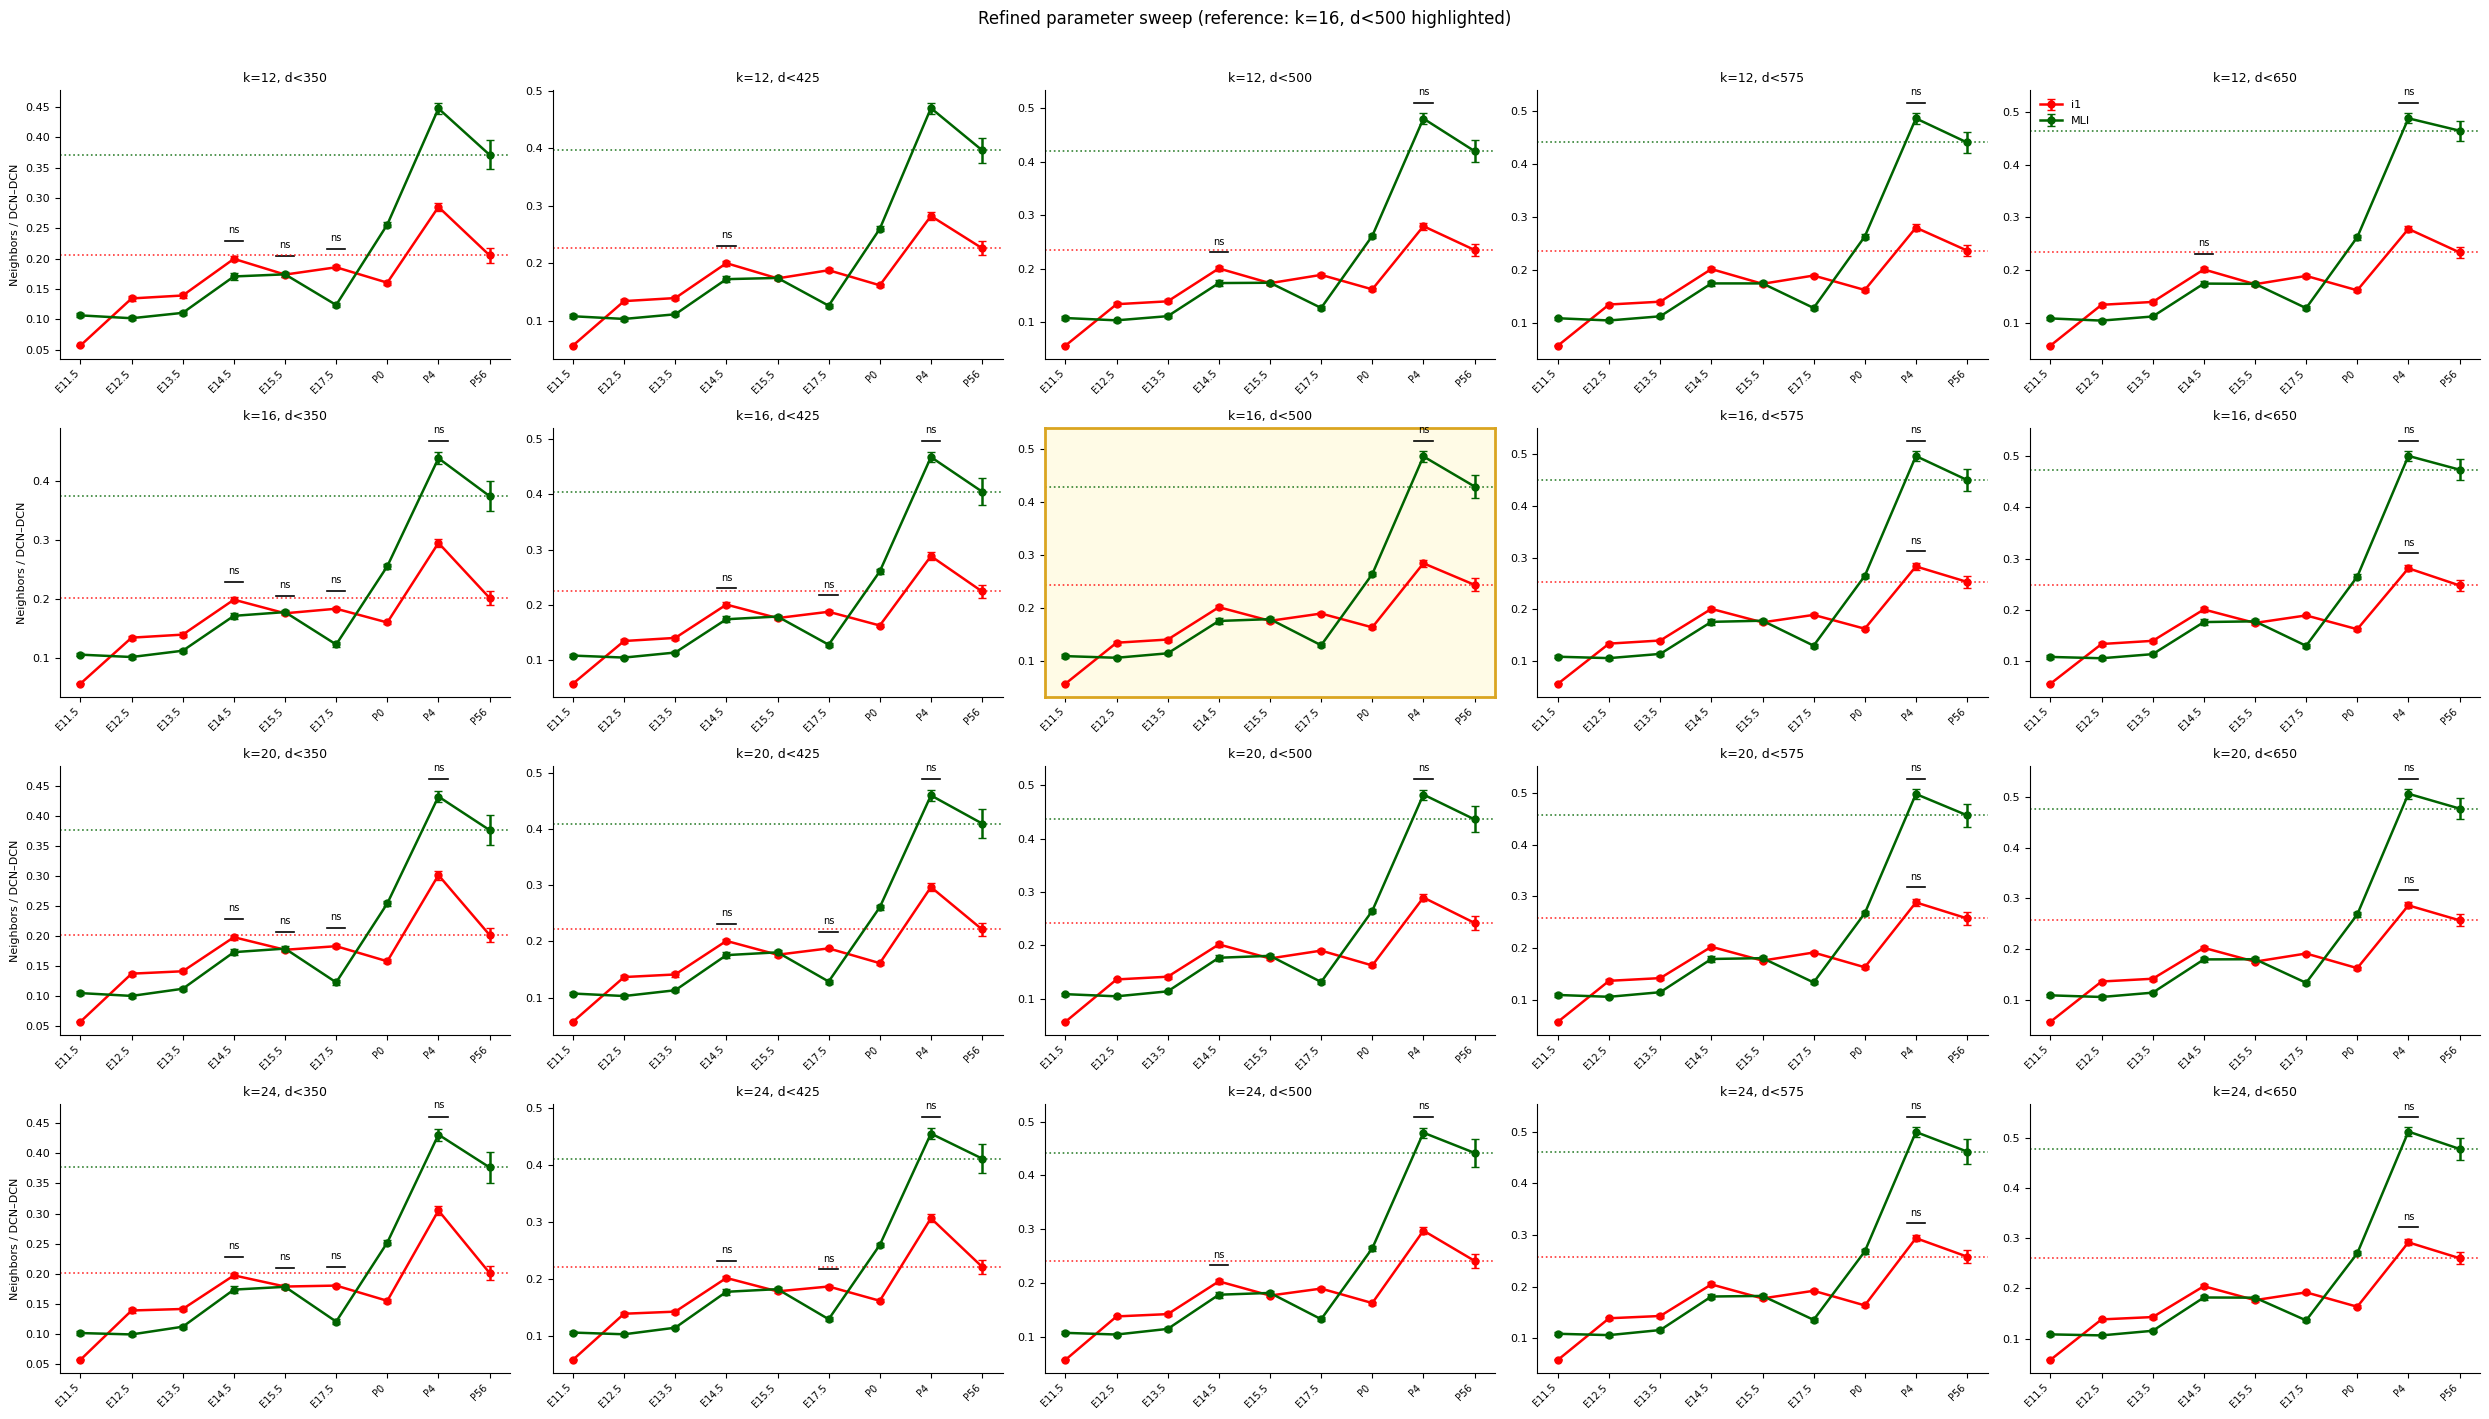

In [66]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from scipy.stats import sem, ttest_ind
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["svg.fonttype"] = "none"

datasets = {
    "E11.5": e11,
    "E12.5": e12,
    "E13.5": e13,
    "E14.5": e14,
    "E15.5": e15,
    "E17.5": e17,
    "P0": p0,
    "P4": p4,
    "P56": p56
}

order = ["E11.5","E12.5","E13.5","E14.5","E15.5","E17.5","P0","P4","P56"]

groups = ["i1","MLI"]
allowed = ["i1","MLI","DCN"]

colors = {"i1": "red", "MLI": "darkgreen"}

# -------------------------
# refined parameter grid around k=16, d=500
# -------------------------
k_values    = [12, 16, 20, 24]
dist_values = [350, 425, 500, 575, 650]

# -------------------------
# helper: compute df for one (k, max_dist)
# -------------------------
def compute_ratios(k, max_dist):

    rows = []
    raw_rows = []

    for tp, adat in datasets.items():

        coords = adat.obsm["spatial"]
        labels = adat.obs["cell_types_collapsed"].values

        allowed_mask = np.isin(labels, allowed)
        coords_allowed = coords[allowed_mask]
        labels_allowed = labels[allowed_mask]

        nn = NearestNeighbors(n_neighbors=k + 1).fit(coords_allowed)
        distances, idx_allowed = nn.kneighbors(coords_allowed)

        dcn_idx = np.where(labels_allowed == "DCN")[0]

        if len(dcn_idx) == 0:
            continue

        counts = {"DCN": [], "i1": [], "MLI": []}

        for i in dcn_idx:

            pairs = list(zip(idx_allowed[i][1:], distances[i][1:]))
            neigh = [j for j, d in pairs if d < max_dist]

            if len(neigh) == 0:
                continue

            neigh_labels = labels_allowed[neigh]

            counts["DCN"].append(np.sum(neigh_labels == "DCN"))
            counts["i1"].append(np.sum(neigh_labels == "i1"))
            counts["MLI"].append(np.sum(neigh_labels == "MLI"))

        if len(counts["DCN"]) == 0:
            continue

        mean_dcn = np.mean(counts["DCN"])

        if mean_dcn == 0:
            continue

        for g in groups:

            ratio = np.array(counts[g]) / mean_dcn

            rows.append({
                "Timepoint": tp,
                "Group": g,
                "Mean": np.mean(ratio),
                "SEM": sem(ratio)
            })

            for r in ratio:
                raw_rows.append({
                    "Timepoint": tp,
                    "Group": g,
                    "Ratio": r
                })

    return pd.DataFrame(rows), pd.DataFrame(raw_rows)


# -------------------------
# helper: draw one axes panel
# -------------------------
def draw_panel(ax, df, raw_df, title):

    if df.empty:
        ax.set_title(title + "\n(no data)")
        return

    present = df["Timepoint"].unique()
    plot_order = [tp for tp in order if tp in present]
    x = np.arange(len(plot_order))

    p56_values = {}

    for g in groups:

        sub = df[df.Group == g].set_index("Timepoint")

        if not all(tp in sub.index for tp in plot_order):
            continue

        sub = sub.loc[plot_order].reset_index()

        ax.errorbar(
            x,
            sub["Mean"],
            yerr=sub["SEM"],
            marker="o",
            markersize=5,
            linewidth=1.8,
            capsize=3,
            label=g,
            color=colors[g]
        )

        p56_values[g] = sub.loc[sub["Timepoint"] == "P56", "Mean"].values[0] \
            if "P56" in sub["Timepoint"].values else None

        if raw_df.empty:
            continue

        p56_raw = raw_df[
            (raw_df.Group == g) & (raw_df.Timepoint == "P56")
        ]["Ratio"].values

        for i, tp in enumerate(plot_order):

            if tp == "P56" or len(p56_raw) == 0:
                continue

            tp_raw = raw_df[
                (raw_df.Group == g) & (raw_df.Timepoint == tp)
            ]["Ratio"].values

            if len(tp_raw) == 0:
                continue

            _, p = ttest_ind(tp_raw, p56_raw, equal_var=False, nan_policy="omit")

            if p >= 0.003125:

                y = sub.loc[sub.Timepoint == tp, "Mean"].values[0]

                ax.plot(
                    [i - 0.18, i + 0.18],
                    [y + 0.03, y + 0.03],
                    color="black", linewidth=1.2
                )
                ax.text(
                    i, y + 0.04, "ns",
                    ha="center", va="bottom",
                    fontsize=7, color="black"
                )

    for g, val in p56_values.items():
        if val is not None:
            ax.axhline(val, linestyle=":", linewidth=1.2, color=colors[g], alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(plot_order, fontsize=7, rotation=45, ha="right")
    ax.set_title(title, fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="y", labelsize=8)


# -------------------------
# build grid: rows=k, cols=max_dist
# -------------------------
nrows = len(k_values)
ncols = len(dist_values)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(5 * ncols, 3.5 * nrows),
    sharey=False
)

for ri, k in enumerate(k_values):
    for ci, max_dist in enumerate(dist_values):

        ax = axes[ri][ci]

        df, raw_df = compute_ratios(k, max_dist)

        title = f"k={k}, d<{max_dist}"

        draw_panel(ax, df, raw_df, title)

        if ci == 0:
            ax.set_ylabel("Neighbors / DCN–DCN", fontsize=8)

        if ri == 0 and ci == ncols - 1:
            ax.legend(frameon=False, fontsize=8)

# highlight the k=16, d=500 panel as reference
ref_ri = k_values.index(16)
ref_ci = dist_values.index(500)
axes[ref_ri][ref_ci].patch.set_facecolor("#fffbe6")
axes[ref_ri][ref_ci].patch.set_alpha(1)
for spine in axes[ref_ri][ref_ci].spines.values():
    spine.set_edgecolor("goldenrod")
    spine.set_linewidth(2)
    spine.set_visible(True)

fig.suptitle(
    "Refined parameter sweep (reference: k=16, d<500 highlighted)",
    fontsize=12, y=1.01
)

plt.tight_layout()

plt.savefig(
    "figure3/inhibitory_neighbors_param_sweep_refined.svg",
    bbox_inches="tight"
)

plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

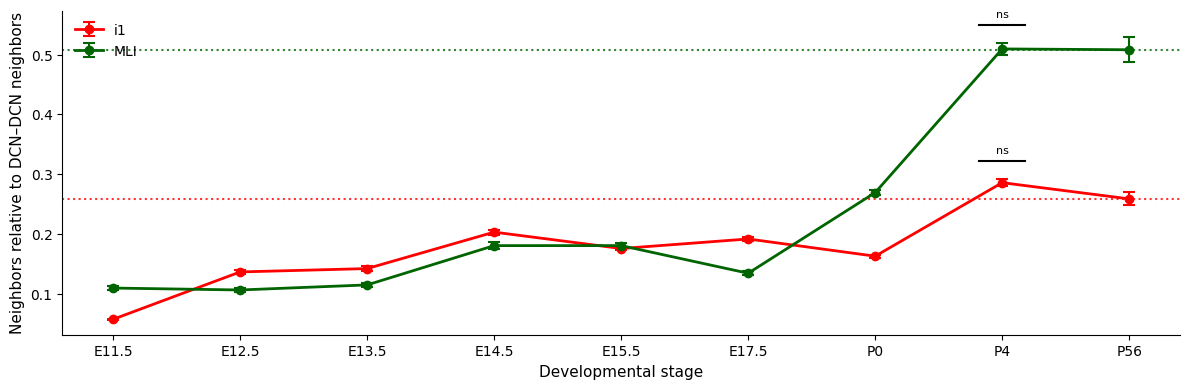

In [79]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from scipy.stats import sem, ttest_ind
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["svg.fonttype"] = "none"

datasets = {
    "E11.5": e11,
    "E12.5": e12,
    "E13.5": e13,
    "E14.5": e14,
    "E15.5": e15,
    "E17.5": e17,
    "P0": p0,
    "P4": p4,
    "P56": p56
}

order = ["E11.5","E12.5","E13.5","E14.5","E15.5","E17.5","P0","P4","P56"]

k = 20
max_dist = 750

groups = ["i1","MLI"]
allowed = ["i1","MLI","DCN"]

colors = {"i1": "red", "MLI": "darkgreen"}

# -------------------------
# compute neighbor ratios
# -------------------------
rows = []
raw_rows = []

for tp, adat in datasets.items():

    coords = adat.obsm["spatial"]
    labels = adat.obs["cell_types_collapsed"].values

    allowed_mask = np.isin(labels, allowed)
    coords_allowed = coords[allowed_mask]
    labels_allowed = labels[allowed_mask]

    nn = NearestNeighbors(n_neighbors=k + 1).fit(coords_allowed)
    distances, idx_allowed = nn.kneighbors(coords_allowed)

    dcn_idx = np.where(labels_allowed == "DCN")[0]

    if len(dcn_idx) == 0:
        continue

    counts = {"DCN": [], "i1": [], "MLI": []}

    for i in dcn_idx:

        pairs = list(zip(idx_allowed[i][1:], distances[i][1:]))
        neigh = [j for j, d in pairs if d < max_dist]

        if len(neigh) == 0:
            continue

        neigh_labels = labels_allowed[neigh]

        counts["DCN"].append(np.sum(neigh_labels == "DCN"))
        counts["i1"].append(np.sum(neigh_labels == "i1"))
        counts["MLI"].append(np.sum(neigh_labels == "MLI"))

    if len(counts["DCN"]) == 0:
        print(f"WARNING: {tp} — no DCN cells had neighbors within max_dist={max_dist}")
        continue

    mean_dcn = np.mean(counts["DCN"])

    if mean_dcn == 0:
        print(f"WARNING: {tp} — mean DCN–DCN neighbors is 0, skipping")
        continue

    for g in groups:

        ratio = np.array(counts[g]) / mean_dcn

        rows.append({
            "Timepoint": tp,
            "Group": g,
            "Mean": np.mean(ratio),
            "SEM": sem(ratio)
        })

        for r in ratio:
            raw_rows.append({
                "Timepoint": tp,
                "Group": g,
                "Ratio": r
            })

df = pd.DataFrame(rows)
raw_df = pd.DataFrame(raw_rows)

# -------------------------
# plot
# -------------------------
# -------------------------
# plot
# -------------------------
fig, ax = plt.subplots(figsize=(12, 4))

x = np.arange(len(order))

p56_values = {}

for g in groups:

    d = (
        df[df.Group == g]
        .set_index("Timepoint")
        .reindex(order)
        .reset_index()
    )

    ax.errorbar(
        x,
        d["Mean"],
        yerr=d["SEM"],          # error bars per timepoint
        marker="o",
        markersize=6,
        linewidth=2,
        elinewidth=1.5,
        capsize=4,
        capthick=1.5,
        label=g,
        color=colors[g]
    )

    p56_values[g] = d.loc[d["Timepoint"] == "P56", "Mean"].values[0]

    p56_raw = raw_df[
        (raw_df.Group == g) &
        (raw_df.Timepoint == "P56")
    ]["Ratio"].values

    for i, tp in enumerate(order):

        if tp == "P56":
            continue

        tp_raw = raw_df[
            (raw_df.Group == g) &
            (raw_df.Timepoint == tp)
        ]["Ratio"].values

        if len(tp_raw) == 0 or len(p56_raw) == 0:
            continue

        _, p = ttest_ind(
            tp_raw,
            p56_raw,
            equal_var=False,
            nan_policy="omit"
        )

        if p >= 0.003125:

            y = d.loc[d.Timepoint == tp, "Mean"].values[0]
            yerr = d.loc[d.Timepoint == tp, "SEM"].values[0]

            if np.isnan(y):
                continue

            if np.isnan(yerr):
                yerr = 0

            ax.plot(
                [i - 0.18, i + 0.18],
                [y + yerr + 0.03, y + yerr + 0.03],
                color="black",
                linewidth=1.5
            )

            ax.text(
                i,
                y + yerr + 0.04,
                "ns",
                ha="center",
                va="bottom",
                fontsize=8,
                color="black"
            )

for g in groups:
    ax.axhline(
        p56_values[g],
        linestyle=":",
        linewidth=1.5,
        color=colors[g],
        alpha=0.8
    )

# -------------------------
# formatting
# -------------------------
ax.set_xticks(x)
ax.set_xticklabels(order)

ax.set_ylabel(
    "Neighbors relative to DCN–DCN neighbors",
    fontsize=11
)

ax.set_xlabel(
    "Developmental stage",
    fontsize=11
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", labelsize=10)

ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper left"
)

plt.tight_layout()


plt.savefig(
    "figure3/inhibitory_neighbors_over_development.svg",
    bbox_inches="tight"
)

plt.show()

In [71]:
df

,Timepoint,Group,Mean,SEM
0,E11.5,i1,0.142298,0.001046
1,E11.5,MLI,0.115447,0.001014
2,E12.5,i1,0.142368,0.001041
3,E12.5,MLI,0.115000,0.001006
4,E13.5,i1,0.141952,0.001038
5,E13.5,MLI,0.114860,0.001002
6,E14.5,i1,0.142295,0.001039
7,E14.5,MLI,0.115136,0.001002
8,E15.5,i1,0.142130,0.001036
9,E15.5,MLI,0.114944,0.000997


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

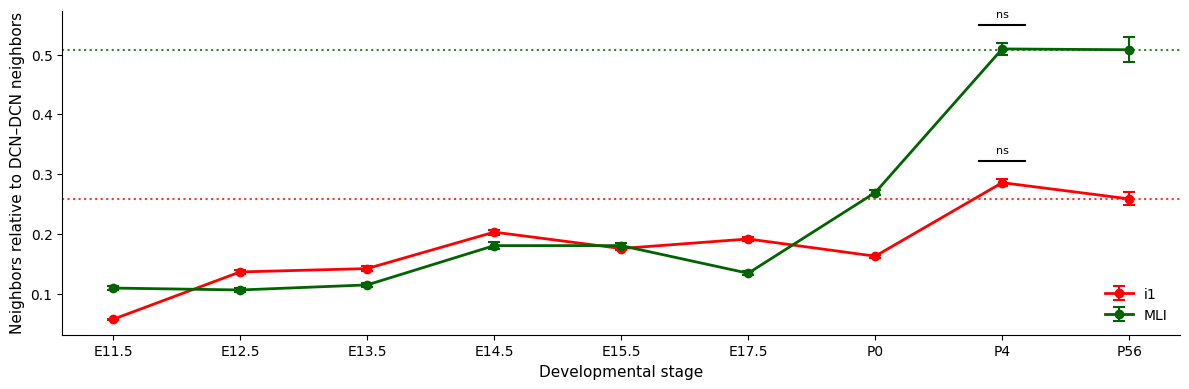